<a href="https://colab.research.google.com/github/jyryu3161/2026_abp/blob/main/Lab03_HER2_trastuzumab_AntiFold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 3. HER2–trastuzumab 복합체에서 항체 CDR sequence 최적화
### PDB 1N8Z + ANARCI(IMGT numbering) + AntiFold

**학습목표**

1. 실제 therapeutic antibody–antigen complex를 구조적으로 분석한다.
2. 항체 sequence의 FR/CDR 개념과 IMGT numbering의 의미를 이해한다.
3. PDB 1N8Z를 AntiFold가 사용할 수 있도록 **IMGT-numbered variable-domain complex**로 전처리한다.
4. AntiFold inverse folding으로 **CDR-H3 중심** antibody variants를 생성한다.
5. mutation 수, interface residue, sequence liability를 이용해 후보를 filtering한다.

### 대상 구조
PDB **1N8Z**
- trastuzumab light chain: **A**
- trastuzumab heavy chain: **B**
- HER2 extracellular domain: **C**
- X-ray structure, 약 2.5 Å

https://www.rcsb.org/structure/1N8Z

- **HER2 (Human Epidermal Growth Factor Receptor 2)**: 세포 표면에 존재하는 수용체 단백질로, 세포의 성장과 증식 신호를 전달합니다. 일부 암에서 HER2가 과도하게 발현되거나 활성화되어 암세포의 성장을 촉진할 수 있습니다.

- **트라스트주맙(Trastuzumab)**: HER2를 표적으로 하는 단일클론 항체(monoclonal antibody)입니다. HER2의 세포외 영역에 결합하여 HER2 신호를 억제하고, 면역계가 HER2를 발현하는 암세포를 공격하도록 돕습니다.

### **Protein MPNN (ProteinMPNN)**

주어진 단백질 3D backbone 구조를 보고, 그 구조를 안정적으로 형성할 가능성이 높은 아미노산 sequence를 설계하는 모델입니다.

- 입력: 단백질 backbone 구조
- 출력: 해당 구조에 적합한 sequence
- 주 용도: 일반적인 protein sequence design
- 핵심 질문: "이 구조를 만들려면 어떤 sequence가 좋을까?"

### **AntiFold**

ProteinMPNN의 아이디어를 항체(antibody)에 특화한 sequence design 모델이라고 이해하면 좋습니다. 특히 항체의 구조적 특성과 CDR의 다양성 등을 고려하여 항체 sequence를 설계/최적화하는 데 초점을 둡니다.

- 입력: 항체 구조/sequence 정보
- 출력: 구조를 유지하거나 목표 구조에 맞는 항체 sequence
- 주 용도: antibody sequence design/design optimization
- 핵심 질문: "이 항체 구조를 유지하면서 어떤 항체 sequence가 가능할까?"

즉, 아주 간단히 말하면:

- **ProteinMPNN** = 일반 단백질용 sequence design
- **AntiFold** = 항체에 특화된 sequence design

### 핵심 툴
- **ANARCI**: antibody variable domain을 IMGT numbering으로 정렬
- **AntiFold**: antibody-specific inverse folding. 구조에 맞는 sequence probability와 sequence sampling
- **BioPython**: PDB 전처리 및 antibody–antigen interface 분석

AntiFold는 sampling 시 IMGT-numbered antibody variable-domain structure를 요구합니다.

> **실행 환경**: Google Colab (Python 3.12 / 3.13), CPU 또는 T4 GPU.
> AntiFold 저장소는 Python 3.10 기준으로 고정된 의존성을 갖고 있어 그대로 설치하면 실패합니다.
> 아래 설치 셀이 이를 우회하는 방식으로 구성되어 있습니다. 셀을 **위에서부터 순서대로** 실행하세요.

In [ ]:
#@title 0. 실행 환경 확인
import sys, platform, subprocess

print("Python  :", sys.version.split()[0])
print("Platform:", platform.platform())

try:
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"], text=True)
    print("GPU     :", out.strip())
except Exception:
    print("GPU     : 감지되지 않음 (CPU로도 실습은 가능하지만 느립니다)")
    print("          Colab 메뉴: 런타임 → 런타임 유형 변경 → T4 GPU")

Python  : 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
GPU     : Tesla T4, 15360 MiB


### 실습 설정 값

아래 셀은 계산을 하지 않고, 뒤 셀들이 참조할 전역 파라미터만 정의합니다. `#@param`은 Colab 폼 위젯 문법입니다.

| 변수 | 기본값 | 무엇을 정하나 | 쓰이는 곳 |
|---|---|---|---|
| `FAST_MODE` | False | 수업 단축용 스위치. True면 `N_VARIANTS`를 10 이하로, False면 최소 30으로 맞춤 | 같은 셀 |
| `N_VARIANTS` | 30 | **온도 1개당** 생성할 변이 서열 수 | 셀 11 |
| `SAMPLING_TEMP` | "0.20" | sampling 온도 | 셀 11 |
| `REGIONS` | "CDRH3" | redesign할 heavy chain IMGT 구간 | 셀 10–16 |
| `ANTIGEN_CROP_DISTANCE` | 12.0 | 항체 원자로부터 이 거리(Å) 안에 있는 HER2 residue만 남김 | 셀 9 |

`REGIONS`에 잘못된 이름이 들어가면 이 셀에서 바로 멈춥니다. 셀 15까지 갔다가 깨지는 것을 앞에서 막는 장치입니다.

`REGIONS`를 `"CDRH1 CDRH2 CDRH3"`처럼 바꾸면 AntiFold 실행부터 sanity check, 변이 집계, 후보 선정까지 전부 그 구간을 따라갑니다. 쓸 수 있는 값은 셀 11 앞의 표에 있습니다.


In [ ]:
#@title 1. 실습 설정
FAST_MODE = False      #@param {type:"boolean"}
N_VARIANTS = 30       #@param {type:"integer"}
SAMPLING_TEMP = "0.20"  #@param {type:"string"}
REGIONS = "CDRH3"     #@param {type:"string"}
ANTIGEN_CROP_DISTANCE = 12.0  #@param {type:"number"}

if FAST_MODE:
    N_VARIANTS = min(N_VARIANTS, 10)
else:
    N_VARIANTS = max(N_VARIANTS, 30)

# AntiFold의 IMGT 구간 정의 (antifold/antiscripts.py의 IMGT_dict와 동일).
# 아래 분석 셀은 heavy chain만 보므로 heavy 구간만 허용합니다.
IMGT_RANGES = {
    "CDRH1": (27, 38), "CDRH2": (56, 65), "CDRH3": (105, 117),
    "FWH1": (1, 26), "FWH2": (39, 55), "FWH3": (66, 104), "FWH4": (118, 128),
}

DESIGN_REGIONS = REGIONS.split()
unknown = [r for r in DESIGN_REGIONS if r not in IMGT_RANGES]
if unknown:
    raise ValueError(f"지원하지 않는 region {unknown}. "
                     f"heavy chain 구간만 사용할 수 있습니다: {sorted(IMGT_RANGES)}")
DESIGN_RANGES = [IMGT_RANGES[r] for r in DESIGN_REGIONS]

def in_design_regions(imgt_pos):
    """IMGT 번호가 redesign 대상 구간에 속하는지."""
    return any(lo <= imgt_pos <= hi for lo, hi in DESIGN_RANGES)

print("변이체 수     :", N_VARIANTS)
print("sampling 온도 :", SAMPLING_TEMP)
print("redesign 구간 :",
      ", ".join(f"{r}({lo}-{hi})" for r, (lo, hi) in zip(DESIGN_REGIONS, DESIGN_RANGES)))


변이체 수     : 30
sampling 온도 : 0.20
redesign 구간 : CDRH3(105-117)


### **AntiFold**의 --sampling_temp에서 temperature란?

**sampling_temp**는 Sequence sampling에서 사용하는 확률 분포의 temperature parameter입니다.

모델이 각 위치에서 다음과 같은 amino acid 확률을 예측한다고 생각해봅시다.

예를 들어:

```
A : 0.60
G : 0.20
S : 0.10
V : 0.05
...
```

Temperature를 이용하면 이 확률 분포를 더 **sharp**하게 만들거나 더 **flat**하게 만들 수 있습니다.

**Temperature가 낮으면**

가장 높은 score를 가진 amino acid의 확률이 매우 커집니다.

즉,

> **낮은 temperature → 모델의 가장 자신 있는 sequence를 선택하는 경향 → sampling 다양성 감소**

**Temperature가 높으면**

probability distribution이 상대적으로 평평해집니다.

따라서 낮은 확률의 amino acid도 sampling될 가능성이 증가합니다.

> **높은 temperature → 더 다양한 sequence sampling → diversity 증가**

개념적으로:
```
Low T
A  █████████████
G  █
S  ▏
V  ▏

High T
A  █████
G  ████
S  ███
V  ██
```
라고 생각하면 됩니다.

## 1. 환경 설치

AntiFold는 ESM-IF1 기반의 antibody-specific inverse-folding 모델입니다.
일반 ProteinMPNN과 달리 antibody structure와 CDR/FR 특성을 반영하도록 fine-tuning되어 있습니다.

무료 T4에서 **sequence sampling 자체는 충분히 가볍습니다.** 가장 중요한 부분은 정확한 chain과 IMGT numbering입니다.


AntiFold의 `requirements.txt`는 다음과 같이 고정되어 있습니다.

```
torch==2.2   numpy==1.26.*   biotite==0.38   torch_geometric==2.4.0   pandas==2.*
```

이 조합은 Python 3.10 기준이며, 현재 Colab(Python 3.12/3.13)에서는

- `numpy==1.26.*`, `biotite==0.38`, `torch==2.2` 의 **wheel이 존재하지 않아** 소스 빌드로 넘어가 실패하고,
- 설치가 되더라도 Colab에 미리 깔린 **CUDA torch를 CPU 버전으로 덮어써** GPU를 못 쓰게 됩니다.

그래서 이 노트북은 **AntiFold를 pip로 설치하지 않고 저장소를 clone해서 소스로 실행**하며,
최신 라이브러리와의 API 차이는 아래 셀에서 소스 패치로 해결합니다.

In [ ]:
#@title 2. 시스템 / 파이썬 패키지 설치
import shutil, sys

# ANARCI는 pip 패키지에 HMM 프로파일만 들어 있고, 정렬 실행에는 hmmscan 바이너리가 필요합니다.
if shutil.which("hmmscan") is None:
    !apt-get -qq install -y hmmer > /dev/null 2>&1

# AntiFold(ESM-IF1) 실행에 실제로 필요한 런타임만 설치합니다.
#  - biotite        : PDB 파싱 (AntiFold 내부)
#  - torch_geometric: GVP encoder의 MessagePassing (순수 python 패키지)
#  - anarci         : IMGT numbering
# torch / numpy / pandas 는 Colab 기본 버전을 그대로 사용합니다 (덮어쓰지 않음).
!pip -q install "anarci>=2026.2.13.2" biopython biotite torch_geometric py3Dmol

print("hmmscan:", shutil.which("hmmscan"))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 110.2 MB/s eta 0:00:00
hmmscan: /usr/bin/hmmscan


In [ ]:
#@title 3. AntiFold clone + 최신 라이브러리 호환 패치
import os, sys, pathlib

ANTIFOLD_DIR = pathlib.Path("AntiFold").resolve()

if not ANTIFOLD_DIR.exists():
    !git clone -q https://github.com/oxpig/AntiFold.git {ANTIFOLD_DIR}


def apply_patch(relpath, old, new):
    p = ANTIFOLD_DIR / relpath
    src = p.read_text()
    if new in src:
        print("이미 적용됨 :", relpath)
    elif old not in src:
        print("패턴 없음   :", relpath, "(AntiFold 버전이 바뀌었을 수 있음)")
    else:
        p.write_text(src.replace(old, new))
        print("패치 완료   :", relpath)


# (1) biotite 1.0에서 filter_backbone -> filter_peptide_backbone 으로 이름이 변경됨.
#     구버전에서도 동작하도록 fallback import로 바꿉니다.
OLD_IMPORT = "from biotite.structure import filter_backbone, get_chains"
NEW_IMPORT = (
    "from biotite.structure import get_chains\n"
    "try:\n"
    "    from biotite.structure import filter_backbone\n"
    "except ImportError:  # biotite >= 1.0\n"
    "    from biotite.structure import filter_peptide_backbone as filter_backbone"
)
for f in ["antifold/esm/inverse_folding/util.py", "antifold/esm_util_custom.py"]:
    apply_patch(f, OLD_IMPORT, NEW_IMPORT)

# (2) main.py는 sys.path에 Path 객체를 넣는데, 최신 Python은 문자열이 아닌 sys.path 항목을
#     무시하므로 `python AntiFold/antifold/main.py` 실행 시 ModuleNotFoundError: antifold 가 납니다.
apply_patch("antifold/main.py",
            "sys.path.insert(0, ROOT_PATH)",
            "sys.path.insert(0, str(ROOT_PATH))")

# 노트북 안에서 import 할 때와 CLI로 실행할 때 모두 저장소를 찾도록 설정
sys.path.insert(0, str(ANTIFOLD_DIR))
os.environ["PYTHONPATH"] = str(ANTIFOLD_DIR)

패치 완료   : antifold/esm/inverse_folding/util.py
패치 완료   : antifold/esm_util_custom.py
패치 완료   : antifold/main.py


In [ ]:
#@title 4. 설치 검증
import torch, biotite, anarci, Bio
import antifold.antiscripts  # AntiFold import가 여기서 깨지면 위 셀을 다시 실행하세요

print("torch      :", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("biotite    :", biotite.__version__)
print("biopython  :", Bio.__version__)
print("AntiFold   :", ANTIFOLD_DIR)
print("설치 확인 완료")

torch      : 2.11.0+cu128 | CUDA: True
biotite    : 1.7.1
biopython  : 1.88
AntiFold   : /content/AntiFold
설치 확인 완료


In [ ]:
#@title 5. PDB 구조 분석용 공통 함수
from Bio.PDB import PDBParser, PDBIO, Select, NeighborSearch
from Bio.SeqUtils import seq1
from pathlib import Path
import numpy as np, pandas as pd, urllib.request

parser = PDBParser(QUIET=True)

def download_pdb(pdb_id, outfile=None):
    pdb_id = pdb_id.upper()
    outfile = outfile or f"{pdb_id}.pdb"
    if not Path(outfile).exists():
        urllib.request.urlretrieve(
            f"https://files.rcsb.org/download/{pdb_id}.pdb", outfile)
    return outfile

def chain_residues(structure, chain_id):
    chain = structure[0][chain_id]
    return [r for r in chain if r.id[0] == " " and "CA" in r]

def chain_sequence(structure, chain_id):
    aas = []
    for r in chain_residues(structure, chain_id):
        try:
            aas.append(seq1(r.resname))
        except Exception:
            aas.append("X")
    return "".join(aas)

def interface_residues(structure, chain_a, chain_b, cutoff=5.0):
    """chain_a에서 chain_b 원자와 cutoff Å 이내에 있는 residue 반환."""
    a_res = chain_residues(structure, chain_a)
    b_atoms = [atom for r in chain_residues(structure, chain_b) for atom in r.get_atoms()]
    ns = NeighborSearch(b_atoms)
    hits = []
    for r in a_res:
        mind = np.inf
        for atom in r.get_atoms():
            neigh = ns.search(atom.coord, cutoff, level="A")
            if neigh:
                mind = min(mind, min(np.linalg.norm(atom.coord - x.coord) for x in neigh))
        if np.isfinite(mind):
            hits.append((r.id[1], r.resname, round(float(mind), 2)))
    return pd.DataFrame(hits, columns=["resseq", "resname", "min_distance"])

## 2. 1N8Z 확인 및 antibody–HER2 interface 분석

먼저 원본 구조를 읽어 antibody heavy/light와 antigen chain을 확인합니다.

### 항체 sequence의 FR / CDR

항체 가변 부위의 sequence는 크게
- **Framework Region (FR)**
- **Complementarity-Determining Region (CDR)**

으로 나눕니다.

**FR (Framework Region)**

FR은 항체 variable domain의 구조적인 골격입니다.

- CDR을 지지하는 역할
- antibody variable domain의 전체적인 fold를 유지
- 상대적으로 sequence conservation이 높음

**CDR (Complementarity-Determining Region)**

CDR은 항원과 직접 상호작용하는 데 중요한 hypervariable region입니다.

특히:

- CDR-H1
- CDR-H2
- CDR-H3
- CDR-L1
- CDR-L2
- CDR-L3

가 있습니다.

여기서 **H = heavy chain**, **L = light chain**입니다.

특히 **CDR-H3**는 항체마다 sequence와 구조적 다양성이 매우 커서 항원 결합 특이성을 결정하는 데 중요한 경우가 많습니다.

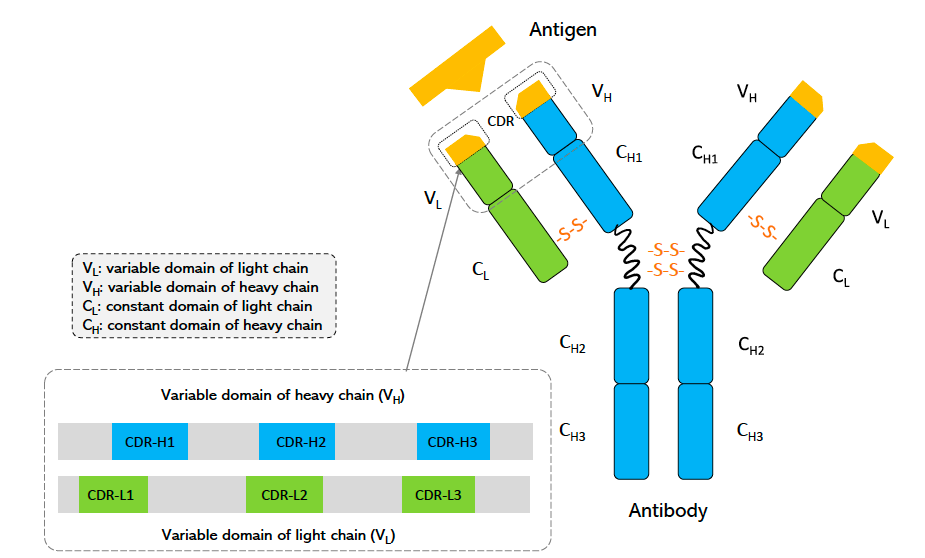

Ref: *Gao et al., KDD (2023)*

In [ ]:
#@title 6. PDB 1N8Z 다운로드 및 interface 분석
pdb_file = download_pdb("1N8Z")
structure = parser.get_structure("1N8Z", pdb_file)

print("Chains:", [c.id for c in structure[0]])
for c in ["A", "B", "C"]:
    print(c, len(chain_residues(structure, c)), chain_sequence(structure, c)[:30] + "...")

# heavy(B) - HER2(C), light(A) - HER2(C) 접촉
h_contacts = interface_residues(structure, "B", "C", cutoff=5.0)
l_contacts = interface_residues(structure, "A", "C", cutoff=5.0)

print("\nHeavy-chain interface residues (원본 PDB numbering)")
display(h_contacts)
print("Light-chain interface residues (원본 PDB numbering)")
display(l_contacts)

Chains: ['A', 'B', 'C']
A 214 DIQMTQSPSSLSASVGDRVTITCRASQDVN...
B 220 EVQLVESGGGLVQPGGSLRLSCAASGFNIK...
C 581 TQVCTGTDMKLRLPASPETHLDMLRHLYQG...

Heavy-chain interface residues (원본 PDB numbering)


,resseq,resname,min_distance
0,33,TYR,3.42
1,50,ARG,2.60
2,52,TYR,4.39
3,57,TYR,3.51
4,58,THR,4.11
5,59,ARG,3.43
6,99,TRP,4.05
7,103,GLY,2.42
8,104,PHE,4.27
9,105,TYR,3.32


Light-chain interface residues (원본 PDB numbering)


,resseq,resname,min_distance
0,28,ASP,4.50
1,30,ASN,2.99
2,31,THR,3.05
3,32,ALA,3.69
4,49,TYR,4.64
5,50,SER,3.61
6,53,PHE,3.56
7,91,HIS,2.89
8,92,TYR,2.96
9,93,THR,4.05


In [ ]:
#@title 7. 구조 시각화
import py3Dmol
view = py3Dmol.view(width=900, height=550)
view.addModel(open("1N8Z.pdb").read(), "pdb")
view.setStyle({"chain": "C"}, {"cartoon": {"color": "lightgray"}})
view.setStyle({"chain": "B"}, {"cartoon": {"color": "royalblue"}})
view.setStyle({"chain": "A"}, {"cartoon": {"color": "cyan"}})
view.zoomTo({"chain": ["A", "B"]})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 3. 왜 IMGT numbering이 필요한가?

항체 sequence를 다룰 때 어려운 점 중 하나가 "어떤 residue가 몇 번인가?"입니다.

단순히 sequence의 1, 2, 3, 4... 순서로 numbering하면 서로 비교하기 어렵습니다.

그래서 사용하는 것이 **IMGT numbering**입니다.

**IMGT numbering**은 항체와 T-cell receptor의 variable region을 서로 비교할 수 있도록 만든 표준적인 numbering 체계입니다. 세어서 번호를 붙이는 대신 **1~128번 칸을 미리 정해 놓고** 모든 variable domain을 거기에 끼워 맞춥니다.

| 칸 | 구간 |
|---|---|
| 1–26 | FR1 |
| 27–38 | CDR1 |
| 39–55 | FR2 |
| 56–65 | CDR2 |
| 66–104 | FR3 |
| **105–117** | **CDR3** |
| 118–128 | FR4 |

특정 번호에는 항상 같은 부품이 옵니다.

CDR3 칸은 105–117, 즉 **13자리**입니다. 실제 CDR-H3가 이보다 짧거나 길면 이렇게 맞춥니다.

| CDR-H3 길이 | 처리 | 실제로 붙는 번호 |
|---|---|---|
| 13 | 그대로 채움 | 105 106 107 108 109 110 111 112 113 114 115 116 117 |
| 11 (짧음) | 가운데 번호를 **비움** (gap) | 105 … 110, <s>111 112</s>, 113 … 117 |
| 15 (김) | 가운데에 **insertion code**를 끼움 | 105 … 111, **111A**, **112A**, 112 … 117 |

비는 순서는 111 → 112 → 110 → 113 → 109 → 114 → … 입니다. 가운데에서 바깥으로 번갈아 나갑니다.

여분은 전부 111과 112 사이에만 들어가고, 112쪽부터 한 개씩 번갈아 배정됩니다 (112A → 111A → 112B → 111B …)

양 끝(105, 117 쪽)은 FR과 맞닿아 구조가 보존되는 부분이라 건드리지 않습니다.

서로 길이가 다른 CDR이라도 **IMGT numbering**을 사용하면 특정 위치를 공통된 번호 체계로 표현할 수 있습니다.

이번 실습에서는 가장 다양성이 크고 antigen specificity에 중요한 **CDR-H3**를 우선 redesign합니다.

원본 1N8Z PDB residue 번호는 IMGT 번호가 아니므로 **ANARCI**를 이용해 variable domain을 찾아서 구조 residue 번호를 다시 부여합니다.

In [ ]:
#@title 8. ANARCI로 heavy/light variable-domain IMGT numbering
from anarci import anarci

def get_imgt_numbering(seq, name):
    numbering, alignment_details, hit_tables = anarci(
        [(name, seq)], scheme="imgt", output=False
    )
    if numbering[0] is None:
        raise RuntimeError(
            f"ANARCI failed for {name}. hmmscan이 설치되어 있는지 확인하세요.")
    domain_numbering, start, end = numbering[0][0]
    # ((imgt_number, insertion_code), amino_acid)
    return domain_numbering, start, end, alignment_details[0][0]

seq_H = chain_sequence(structure, "B")
seq_L = chain_sequence(structure, "A")

num_H, start_H, end_H, detail_H = get_imgt_numbering(seq_H, "trastuzumab_H")
num_L, start_L, end_L, detail_L = get_imgt_numbering(seq_L, "trastuzumab_L")

print("Heavy V-domain source index:", start_H, end_H, "type:", detail_H.get("chain_type"))
print("Light V-domain source index:", start_L, end_L, "type:", detail_L.get("chain_type"))

print("Heavy first IMGT residues:", num_H[:10])
print("Light first IMGT residues:", num_L[:10])

Heavy V-domain source index: 0 119 type: H
Light V-domain source index: 0 106 type: K
Heavy first IMGT residues: [((1, ' '), 'E'), ((2, ' '), 'V'), ((3, ' '), 'Q'), ((4, ' '), 'L'), ((5, ' '), 'V'), ((6, ' '), 'E'), ((7, ' '), 'S'), ((8, ' '), 'G'), ((9, ' '), 'G'), ((10, ' '), '-')]
Light first IMGT residues: [((1, ' '), 'D'), ((2, ' '), 'I'), ((3, ' '), 'Q'), ((4, ' '), 'M'), ((5, ' '), 'T'), ((6, ' '), 'Q'), ((7, ' '), 'S'), ((8, ' '), 'P'), ((9, ' '), 'S'), ((10, ' '), 'S')]


## 4. AntiFold 입력 PDB 만들기

AntiFold에는 full Fc/Fab constant region이 필요하지 않습니다.
따라서:

- heavy variable domain → chain **H**
- light variable domain → chain **L**
- HER2는 antibody 근처의 local antigen patch만 crop → chain **Y**

로 새 PDB를 만듭니다.

작은 antigen chain을 권장하는 AntiFold 지침에도 맞고 GPU/메모리도 줄일 수 있습니다.

In [ ]:
#@title 9. IMGT-numbered variable domains + local HER2 patch 생성
from Bio.PDB import Structure, Model, Chain
import copy

H_all = chain_residues(structure, "B")
L_all = chain_residues(structure, "A")
Ag_all = chain_residues(structure, "C")

def numbering_map(domain_numbering, source_residues, start, end):
    src = source_residues[start:end + 1]
    non_gap = [(pos, aa) for pos, aa in domain_numbering if aa != "-"]
    if len(src) != len(non_gap):
        # 일부 구조 residue missing 가능 → sequence/structure 차이를 명확히 경고
        print("WARNING: mapped lengths differ:", len(src), len(non_gap))
    n = min(len(src), len(non_gap))
    return list(zip(src[:n], non_gap[:n]))

H_map = numbering_map(num_H, H_all, start_H, end_H)
L_map = numbering_map(num_L, L_all, start_L, end_L)

# 구조 residue와 ANARCI 서열이 실제로 일치하는지 확인 (frame shift 방지)
for label, mapping in [("H", H_map), ("L", L_map)]:
    bad = [(r.id[1], r.resname, aa) for r, (pos, aa) in mapping if seq1(r.resname) != aa]
    print(f"{label} chain mapping mismatches:", len(bad), bad[:5])

# antigen: antibody variable-domain 원자에서 일정 거리 내 residue만 선택
ab_atoms = [a for r, _ in H_map + L_map for a in r.get_atoms()]
ns_ab = NeighborSearch(ab_atoms)

Ag_crop = [r for r in Ag_all
           if any(ns_ab.search(a.coord, ANTIGEN_CROP_DISTANCE, level="A") for a in r.get_atoms())]

print("H variable residues:", len(H_map))
print("L variable residues:", len(L_map))
print("HER2 cropped residues:", len(Ag_crop))

newS = Structure.Structure("trastuzumab_imgt")
newM = Model.Model(0)
newS.add(newM)

def copy_residue(res, new_id):
    """residue만 복사한다.

    부모(chain/model/structure)가 붙은 채로 deepcopy하면 parent 링크를 따라
    구조 전체가 매번 복사되어 매우 느립니다. 잠시 분리했다가 되돌립니다.
    """
    parent = res.get_parent()
    res.detach_parent()
    new_res = copy.deepcopy(res)
    res.set_parent(parent)
    new_res.id = new_id
    return new_res

def add_imgt_chain(newM, chain_id, mapping):
    ch = Chain.Chain(chain_id)
    newM.add(ch)
    for old_res, (pos, aa) in mapping:
        num, ins = pos
        ch.add(copy_residue(old_res, (" ", int(num), (ins or " ")[:1])))

add_imgt_chain(newM, "H", H_map)
add_imgt_chain(newM, "L", L_map)

Y = Chain.Chain("Y")
newM.add(Y)
for i, old_res in enumerate(Ag_crop, start=1):
    Y.add(copy_residue(old_res, (" ", i, " ")))

# AntiFold는 --pdb_file 의 dirname을 pdb_dir로 사용하므로 파일명만 넘기면
# "/파일명.pdb" 를 찾다가 실패합니다. 반드시 절대경로로 전달합니다.
IMGT_PDB = str(Path("1n8z_trastuzumab_imgt_localHER2.pdb").resolve())
io = PDBIO()
io.set_structure(newS)
io.save(IMGT_PDB)
print("saved:", IMGT_PDB)

H chain mapping mismatches: 0 []
L chain mapping mismatches: 0 []
H variable residues: 120
L variable residues: 107
HER2 cropped residues: 61
saved: /content/1n8z_trastuzumab_imgt_localHER2.pdb


In [ ]:
#@title 10. IMGT PDB sanity check
imgt_structure = parser.get_structure("imgt", IMGT_PDB)

for cid in ["H", "L", "Y"]:
    residues = chain_residues(imgt_structure, cid)
    print(cid, len(residues),
          "first:", residues[0].id if residues else None,
          "last:", residues[-1].id if residues else None)

# redesign 대상 구간이 구조에 실제로 존재하는지.
# 비어 있으면 AntiFold가 에러 없이 WT만 그대로 내놓습니다.
design_res = [r for r in chain_residues(imgt_structure, "H") if in_design_regions(r.id[1])]
for region, (lo, hi) in zip(DESIGN_REGIONS, DESIGN_RANGES):
    modeled = [r for r in design_res if lo <= r.id[1] <= hi]
    print(f"{region} modeled residues:",
          [(r.id[1], r.id[2].strip(), r.resname) for r in modeled])
    if not modeled:
        raise RuntimeError(f"{region}({lo}-{hi})에 해당하는 residue가 구조에 없습니다.")

# IMGT 좌표계에서 다시 계산한 HER2 접촉 residue (뒤의 후보 filtering에 사용)
h_iface_imgt = interface_residues(imgt_structure, "H", "Y", cutoff=5.0)
l_iface_imgt = interface_residues(imgt_structure, "L", "Y", cutoff=5.0)
contact_pos_H = set(h_iface_imgt["resseq"])
print("Heavy chain HER2 contact (IMGT):", sorted(contact_pos_H))
print("  그 중 redesign 구간 내부:", sorted(p for p in contact_pos_H if in_design_regions(p)))


H 120 first: (' ', 1, ' ') last: (' ', 128, ' ')
L 107 first: (' ', 1, ' ') last: (' ', 127, ' ')
Y 61 first: (' ', 1, ' ') last: (' ', 61, ' ')
CDRH3 modeled residues: [(105, '', 'SER'), (106, '', 'ARG'), (107, '', 'TRP'), (108, '', 'GLY'), (109, '', 'GLY'), (110, '', 'ASP'), (111, '', 'GLY'), (112, '', 'PHE'), (113, '', 'TYR'), (114, '', 'ALA'), (115, '', 'MET'), (116, '', 'ASP'), (117, '', 'TYR')]
Heavy chain HER2 contact (IMGT): [38, 55, 57, 64, 65, 66, 107, 111, 112, 113]
  그 중 redesign 구간 내부: [107, 111, 112, 113]


## 5. AntiFold로 CDR-H3 sequence sampling

AntiFold의 기본 아이디어는 structure가 주어졌을 때 각 위치의 amino-acid probability

$$P(a_i \mid backbone,\ structural\ context)$$

를 학습하는 **inverse folding**입니다.

이번 실습은 framework는 고정하고 `REGIONS`로 지정한 구간(기본값 **CDR-H3**)만 sampling합니다.
즉, 처음부터 완전히 새로운 항체를 만드는 실습이 아니라 **structure-guided affinity maturation 후보 생성**에 가깝습니다.

첫 실행 시 AntiFold 모델 가중치(약 195 MB)를 `AntiFold/models/model.pt` 로 자동 다운로드합니다.
- Antifold 입력 PDB  ──▶  [학습된 가중치]  ──▶ 각 잔기마다 20개 아미노산에 대한 점수

### AntiFold CLI 인자

| 인자 | 이 노트북의 값 | 의미 |
|---|---|---|
| `--pdb_file` | `IMGT_PDB` | 입력 구조. AntiFold가 dirname을 pdb_dir로 쓰므로 **절대경로 필수** |
| `--heavy_chain` | `H` | heavy variable domain chain ID |
| `--light_chain` | `L` | light variable domain chain ID |
| `--antigen_chain` | `Y` | 항원 chain. 문맥으로만 쓰이고 **절대 mutate되지 않음** |
| `--num_seq_per_target` | `N_VARIANTS` | 온도당 sampling 개수 (0이면 sampling 없이 CSV만 생성) |
| `--sampling_temp` | `SAMPLING_TEMP` | 확률분포 temperature. 낮으면 sharp, 높으면 flat |
| `--regions` | `REGIONS` | mutate를 허용할 구간. (실습에서는 `CDR H3`) |
| `--seed` | 42 | 재현성 |
| `--out_dir` | `antifold_lab3_output` | 출력 폴더 |

In [ ]:
#@title 11. AntiFold 실행
OUT_DIR = "antifold_lab3_output"
!rm -rf {OUT_DIR}

print(f"sampling_temp = {SAMPLING_TEMP} | regions = {REGIONS}  ->  {OUT_DIR}")

!python {ANTIFOLD_DIR}/antifold/main.py \
    --pdb_file {IMGT_PDB} \
    --heavy_chain H \
    --light_chain L \
    --antigen_chain Y \
    --num_seq_per_target {N_VARIANTS} \
    --sampling_temp "{SAMPLING_TEMP}" \
    --regions "{REGIONS}" \
    --seed 42 \
    --out_dir {OUT_DIR}

print("\nGenerated files:")
!find {OUT_DIR} -type f -print


sampling_temp = 0.20 | regions = CDRH3  ->  antifold_lab3_output
[2026-09-16 04:01:18,884] Running inverse folding on PDB/CIFs ...
[2026-09-16 04:01:18,886] Will sample 30 sequences from 1 PDBs at temperature(s) [0.2] and regions: ['CDRH3']
[2026-09-16 04:01:18,886] Downloading AntiFold model weights from https://opig.stats.ox.ac.uk/data/downloads/AntiFold/models/model.pt to /content/AntiFold/models/model.pt
[2026-09-16 04:01:49,236] Loaded model to cuda.
[2026-09-16 04:01:49,241] NOTE: Custom chain mode enabled. Will run specified chain(s).
[2026-09-16 04:01:49,241] Reading in (1) PDBs from DataFrame
[2026-09-16 04:01:49,529] Predicting batch 1/1: PDBs 1-1 out of 1 total
[2026-09-16 04:01:50,720] Saving 1 CSVs to antifold_lab3_output
[2026-09-16 04:01:50,729] Writing 1n8z_trastuzumab_imgt_localHER2_HLY per-residue log probs CSV to antifold_lab3_output/1n8z_trastuzumab_imgt_localHER2_HLY.csv
[2026-09-16 04:01:50,760] 1n8z_trastuzumab_imgt_localHER2_HLY: , score=0.2160, global_score=0.2

> AntiFold release에 따라 출력 옵션 이름이 바뀌었다면 `!python {ANTIFOLD_DIR}/antifold/main.py -h` 로 현재 CLI를 확인하세요.

### 출력 파일

| 파일 | 내용 |
|---|---|
| `*_HLY.csv` | residue별 20개 아미노산 logit 행렬 (antigen 포함 모든 chain) |
| `*_HLY.fasta` | 첫 record가 wild-type, 이후 record가 sampling된 variant. 서열은 `heavy/light` 형태로 `/` 구분 |

**FASTA description 항목**

| 항목 | 의미 |
|---|---|
| `T` | 이 서열을 뽑은 sampling 온도 |
| `sample` | 몇 번째 sample인지 |
| `score` | `--regions` 구간만의 평균 negative log-likelihood |
| `global_score` | heavy + light 전체의 평균 negative log-likelihood |
| `seq_recovery` | WT와 같은 자리의 비율 |
| `mutations` | WT와 다른 자리 수 (H+L 합계) |


## 6. 변이량과 developability 기초 filtering

수업에서는 지나치게 큰 sequence change를 피하기 위해:

- redesign 구간의 mutation 수
- hydrophobic/aromatic residue 증가
- cysteine 추가
- N-X-S/T glycosylation motif 생성

등을 간단히 확인합니다.

실제 antibody developability 평가에는 더 많은 지표가 필요합니다.

In [ ]:
#@title 12. AntiFold 출력 로드
from pathlib import Path
from Bio import SeqIO

out_dir = Path(OUT_DIR)
fasta_files = sorted(out_dir.rglob("*.fasta"))
csv_files = sorted(out_dir.rglob("*.csv"))
print("FASTA:", fasta_files)
print("CSV  :", csv_files)

if not fasta_files:
    raise FileNotFoundError(
        f"FASTA가 없습니다. {out_dir}/log.txt 를 열어 AntiFold 로그를 확인하세요.")

records = list(SeqIO.parse(str(fasta_files[0]), "fasta"))
logits = pd.read_csv(csv_files[0])

print("\nrecord 수 (WT + N_VARIANTS):", len(records), "(첫 번째는 WT)")
print("logits shape:", logits.shape, "| chains:", sorted(logits["pdb_chain"].unique()))
display(logits.head(3))


FASTA: [PosixPath('antifold_lab3_output/1n8z_trastuzumab_imgt_localHER2_HLY.fasta')]
CSV  : [PosixPath('antifold_lab3_output/1n8z_trastuzumab_imgt_localHER2_HLY.csv')]

record 수 (WT + N_VARIANTS): 31 (첫 번째는 WT)
logits shape: (288, 27) | chains: ['H', 'L', 'Y']


,pdb_posins,pdb_chain,pdb_res,top_res,pdb_pos,perplexity,assumed_region,A,C,D,...,M,N,P,Q,R,S,T,V,W,Y
0,1,H,E,M,1,1.4828,FWH1,-5.3667,-7.3229,-5.7613,...,-0.0631,-6.1451,-5.1339,-6.0655,-5.9665,-5.0147,-5.6585,-5.3191,-7.9247,-7.3939
1,2,H,V,V,2,1.0598,FWH1,-9.1419,-11.8139,-12.2986,...,-8.9891,-11.1428,-11.5362,-10.1189,-11.3013,-13.6275,-9.5805,-0.0094,-11.4749,-11.6800
2,3,H,Q,Q,3,1.2969,FWH1,-7.7137,-10.1736,-8.7951,...,-6.7707,-6.8433,-15.2706,-0.0457,-4.8806,-8.4341,-7.5622,-6.3375,-11.6205,-10.3875


**CSV 컬럼**

| 컬럼 | 의미 |
|---|---|
| `pdb_posins` | IMGT 번호 + insertion code (예: `111A`) |
| `pdb_chain` | H / L / Y |
| `pdb_res` | 구조의 실제 잔기 (WT) |
| `top_res` | Antifold 모델이 가장 선호하는 잔기 |
| `pdb_pos` | 숫자 부분만 뽑은 IMGT 번호 (정수 비교용) |
| `perplexity` | 그 자리의 예측 불확실성, 평균적으로 몇 개의 아미노산 후보가 비슷하게 들어갈만 한지 판단, e^(score) |
| `assumed_region` | `CDRH1` / `FWH2` … 자동 판정된 구간 |
| `A` … `Y` (20열) | 아미노산별 logit |

`pdb_res`와 `top_res`가 다른 자리가 모델이 WT와 다른 잔기를 선호하는 자리입니다. 온도를 아무리 낮춰도 이런 자리는 WT로 돌아오지 않고, 그래서 `n_mut`에는 0으로 내려가지 않는 하한이 생깁니다.

In [ ]:
#@title 13. WT redesign 구간과 sampling 위치 확인
# logits CSV의 H chain row 순서 = FASTA heavy chain 서열 순서
h_rows = logits[logits["pdb_chain"] == "H"].reset_index(drop=True)
design_idx = h_rows.index[h_rows["pdb_pos"].map(in_design_regions)].tolist()
design_labels = [str(x) for x in h_rows.loc[design_idx, "pdb_posins"]]
design_positions = [int(x) for x in h_rows.loc[design_idx, "pdb_pos"]]

def split_HL(record):
    """AntiFold FASTA record는 'heavy/light' 형태."""
    heavy, light = str(record.seq).split("/")
    return heavy, light

wt_H, wt_L = split_HL(records[0])
wt_design = "".join(wt_H[i] for i in design_idx)

# 구조에서 직접 읽은 서열과 일치해야 한다 (frame shift 방지)
assert wt_design == "".join(seq1(r.resname) for r in design_res), \
    "AntiFold 서열과 구조의 redesign 구간이 다릅니다. 셀 9의 IMGT mapping을 확인하세요."

print("redesign 구간:", " + ".join(DESIGN_REGIONS))
print("IMGT 위치    :", design_labels)
print("WT 서열      :", wt_design, "length:", len(wt_design))


redesign 구간: CDRH3
IMGT 위치    : ['105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117']
WT 서열      : SRWGGDGFYAMDY length: 13


### variant 테이블 컬럼

| 컬럼 | 계산 방식 | 해석 |
|---|---|---|
| `variant` | var01, var02 … | 식별자 |
| `design_seq` | `REGIONS` 구간의 잔기만 이어 붙인 서열 | 이 후보에서 실제로 설계된 부분 |
| `n_mut` | WT와 다른 자리 수 | 작을수록 안전. WT가 이미 갖춘 folding·발현·안정성을 그대로 물려받을 확률이 높음 |
| `mutations` | `{WT}{IMGT번호}{변이}` (예: `R112K`) | 변이를 IMGT 번호로 적어 다른 항체와도 바로 대조 가능 |
| `interface_mut` | 변이 위치 중 HER2 접촉 자리(5 Å) 개수 | affinity를 움직일 수 있는 변이의 수. 0이면 결합은 거의 그대로, 클수록 개선 가능성과 결합 상실 위험이 함께 커짐 |
| `d_hydrophobic` | 변이와 WT 간의 소수성·방향족(AVILMFWYC) 개수 차이 | 양수면 표면에 드러난 소수성 patch가 커져 응집·비특이 결합·용해도 저하로 이어짐 |
| `new_cys` | WT에 없던 C 생성 여부 | True면 탈락. 짝을 못 찾은 cysteine이 분자 간 disulfide를 만들어 dimer와 불균일한 생산물을 유발 |
| `new_nglyc` | N-X-S/T (X≠P) 개수가 WT보다 증가했는지 (heavy chain 전체 기준) | True면 탈락. 세포가 이 motif를 인식해 당사슬을 붙이므로 batch마다 다른 물질이 나옴 |

> 구간을 여러 개 설계하면 변이가 인접 framework나 구간 경계와 만나 motif를 만들 수 있어, `new_nglyc`는 설계 구간이 아니라 heavy chain 전체로 셉니다.

#### `score` vs `global_score`

CSV에는 자리마다 20개 아미노산의 −log P가 들어 있습니다. 후보가 가진 잔기의 값을 꺼내 평균 낸 것이 두 점수이고, **평균 범위만 다릅니다.**

| | `score` | `global_score` |
|---|---|---|
| 평균 범위 | `--regions`로 설계한 자리만 (CDR-H3면 13자리) | heavy + light 전체 (약 230자리) |
| 항원(chain Y) | 제외 | 제외 |
| 후보 간 변별력 | 있음. 바뀐 자리가 모두 여기 포함됨 | 거의 없음. 230자리 중 몇 자리만 달라짐 |

- **낮을수록 좋습니다.** 셀 14가 `score` 오름차순으로 정렬하는 이유입니다.
- 절대 합격선은 없습니다. 모델이 20개 잔기를 완전히 동등하게 보는 자리의 값이 ln(20) ≈ 3.0이라 이것이 기준선이고 (무작위 서열은 보통 이보다 큽니다), 실질적인 비교 대상은 WT 자신의 값입니다.
- score가 내려갔다고 affinity가 올라간 것은 아닙니다. 모델은 backbone 적합도만 볼 뿐 결합 에너지를 계산하지 않습니다 (과제 5번).


In [ ]:
#@title 14. variant별 mutation / liability 테이블
import re

HYDROPHOBIC = set("AVILMFWYC")

def n_glyc_sites(seq):
    """N-X-S/T (X != P) sequon 개수."""
    return sum(seq[i] == "N" and seq[i + 1] != "P" and seq[i + 2] in "ST"
               for i in range(len(seq) - 2))

# sequon은 구간 경계나 framework와 맞물려 생길 수 있으므로 heavy chain 전체로 센다.
wt_nglyc = n_glyc_sites(wt_H)
wt_hydro = sum(c in HYDROPHOBIC for c in wt_design)

rows = []
for k, rec in enumerate(records[1:], start=1):
    H, _ = split_HL(rec)
    des = "".join(H[i] for i in design_idx)
    changed = [j for j in range(len(des)) if des[j] != wt_design[j]]
    mut_pos = [design_positions[j] for j in changed]
    meta = dict(re.findall(r"(\w+)=([-\d\.]+)", rec.description))
    rows.append({
        "variant": f"var{k:02d}",
        "design_seq": des,
        "n_mut": len(changed),
        "mutations": ";".join(f"{wt_design[j]}{design_labels[j]}{des[j]}" for j in changed),
        "interface_mut": sum(p in contact_pos_H for p in mut_pos),   # HER2 접촉 위치를 바꾼 수
        "d_hydrophobic": sum(c in HYDROPHOBIC for c in des) - wt_hydro,
        "new_cys": ("C" in des) and ("C" not in wt_design),
        "new_nglyc": n_glyc_sites(H) > wt_nglyc,
        "score": float(meta.get("score", "nan")),
        "global_score": float(meta.get("global_score", "nan")),
    })

variants = (pd.DataFrame(rows)
            .drop_duplicates(subset="design_seq")
            .sort_values(["n_mut", "score"])
            .reset_index(drop=True))

print(f"고유 variant: {len(variants)} / 생성 {len(records) - 1}")
print(f"WT {' + '.join(DESIGN_REGIONS)}: {wt_design}")
print(f"  redesign 구간 안의 HER2 접촉 위치: "
      f"{sorted(p for p in contact_pos_H if in_design_regions(p))}")
display(variants)


고유 variant: 21 / 생성 30
WT CDRH3: SRWGGDGFYAMDY
  redesign 구간 안의 HER2 접촉 위치: [107, 111, 112, 113]


,variant,design_seq,n_mut,mutations,interface_mut,d_hydrophobic,new_cys,new_nglyc,score,global_score
0,var05,ARDYGYAYYAMDY,6,S105A;W107D;G108Y;D110Y;G111A;F112Y,3,3,False,False,0.6366,0.1740
1,var15,ARDLGYAYYAMDY,6,S105A;W107D;G108L;D110Y;G111A;F112Y,3,3,False,False,0.6375,0.1741
2,var19,ARDYGWAYYAMDY,6,S105A;W107D;G108Y;D110W;G111A;F112Y,3,3,False,False,0.6455,0.1745
3,var07,ARDLGWAYYAMDY,6,S105A;W107D;G108L;D110W;G111A;F112Y,3,3,False,False,0.6463,0.1746
4,var18,AREYGYAYYAMDY,6,S105A;W107E;G108Y;D110Y;G111A;F112Y,3,3,False,False,0.6471,0.1746
5,var03,ARELGYAYYAMDY,6,S105A;W107E;G108L;D110Y;G111A;F112Y,3,3,False,False,0.6480,0.1747
6,var22,ARELGWAYYAMDY,6,S105A;W107E;G108L;D110W;G111A;F112Y,3,3,False,False,0.6569,0.1752
7,var25,ARDWGWAYYAMDY,6,S105A;W107D;G108W;D110W;G111A;F112Y,3,3,False,False,0.7238,0.1790
8,var30,ATDYGYAYYAMDY,7,S105A;R106T;W107D;G108Y;D110Y;G111A;F112Y,3,3,False,False,0.6508,0.1748
9,var01,ATDLGYAYYAMDY,7,S105A;R106T;W107D;G108L;D110Y;G111A;F112Y,3,3,False,False,0.6517,0.1749


In [ ]:
#@title 15. 후보 선정
MAX_MUT = 6   #@param {type:"integer"}
TOP_N = 5     #@param {type:"integer"}

clean = variants[(~variants["new_cys"]) & (~variants["new_nglyc"])]
candidates = clean[clean["n_mut"] <= MAX_MUT]

if candidates.empty:
    print(f"mutation {MAX_MUT}개 이하인 후보가 없습니다. "
          f"(최소 mutation 수={variants['n_mut'].min()})")
    print("→ 모델이 WT보다 다른 잔기를 확실히 선호하는 자리가 여럿이기 때문입니다.")
    print("   CSV의 pdb_res와 top_res를 비교하면 그런 자리를 확인할 수 있습니다.")
    print("   MAX_MUT를 현실적인 값으로 올리거나, 아래 목록에서 변이 위치를 보고 직접 고르세요.")
    candidates = clean

candidates = candidates.head(TOP_N)
display(candidates)

candidates.to_csv("lab3_cdrh3_candidates.csv", index=False)
print("saved: lab3_cdrh3_candidates.csv")

for _, row in candidates.iterrows():
    marks = "".join("X" if a != b else "_" for a, b in zip(wt_design, row["design_seq"]))
    print(f"\n{row['variant']}  (n_mut={row['n_mut']}, interface_mut={row['interface_mut']})")
    print(f"  WT   : {wt_design}")
    print(f"  mut  : {row['design_seq']}")
    print(f"  diff : {marks}")


,variant,design_seq,n_mut,mutations,interface_mut,d_hydrophobic,new_cys,new_nglyc,score,global_score
0,var05,ARDYGYAYYAMDY,6,S105A;W107D;G108Y;D110Y;G111A;F112Y,3,3,False,False,0.6366,0.1740
1,var15,ARDLGYAYYAMDY,6,S105A;W107D;G108L;D110Y;G111A;F112Y,3,3,False,False,0.6375,0.1741
2,var19,ARDYGWAYYAMDY,6,S105A;W107D;G108Y;D110W;G111A;F112Y,3,3,False,False,0.6455,0.1745
3,var07,ARDLGWAYYAMDY,6,S105A;W107D;G108L;D110W;G111A;F112Y,3,3,False,False,0.6463,0.1746
4,var18,AREYGYAYYAMDY,6,S105A;W107E;G108Y;D110Y;G111A;F112Y,3,3,False,False,0.6471,0.1746


saved: lab3_cdrh3_candidates.csv

var05  (n_mut=6, interface_mut=3)
  WT   : SRWGGDGFYAMDY
  mut  : ARDYGYAYYAMDY
  diff : X_XX_XXX_____

var15  (n_mut=6, interface_mut=3)
  WT   : SRWGGDGFYAMDY
  mut  : ARDLGYAYYAMDY
  diff : X_XX_XXX_____

var19  (n_mut=6, interface_mut=3)
  WT   : SRWGGDGFYAMDY
  mut  : ARDYGWAYYAMDY
  diff : X_XX_XXX_____

var07  (n_mut=6, interface_mut=3)
  WT   : SRWGGDGFYAMDY
  mut  : ARDLGWAYYAMDY
  diff : X_XX_XXX_____

var18  (n_mut=6, interface_mut=3)
  WT   : SRWGGDGFYAMDY
  mut  : AREYGYAYYAMDY
  diff : X_XX_XXX_____


In [ ]:
#@title 16. 위치별 WT 보존 확률
AA = list("ACDEFGHIKLMNPQRSTVWY")

def softmax_rows(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

# logit 행렬은 구조에서 1회 계산된 고정값이라, 뽑은 샘플을 세지 않고도
# 실제 사용한 온도에서의 확률을 그대로 구할 수 있습니다.
h_design = h_rows.loc[design_idx]
probs = softmax_rows(h_design[AA].values / max(float(SAMPLING_TEMP), 0.001))
p_wt = probs[np.arange(len(design_idx)), [AA.index(a) for a in wt_design]]

conservation = pd.DataFrame({
    "wt": list(wt_design),
    "top_res": h_design["top_res"].values,
    "P(WT) %": (100 * p_wt).round(1),
}, index=design_labels)

print(f"위치별 WT 보존 확률 (T={SAMPLING_TEMP})")
display(conservation)

위치별 WT 보존 확률 (T=0.20)


,wt,top_res,P(WT) %
105,S,A,0.0
106,R,R,54.5
107,W,D,0.0
108,G,Y,0.2
109,G,G,100.0
110,D,Y,0.0
111,G,A,0.1
112,F,Y,0.7
113,Y,Y,99.9
114,A,A,100.0


보존 확률이 0%에 가까운 자리는 **어떤 온도에서도 WT로 돌아오지 않습니다.** 모델이 WT보다 다른 잔기를
확실히 선호하는 자리이고, `top_res` 열이 그 잔기를 보여줍니다. `n_mut`이 0으로 내려가지 않는 하한이
여기서 생깁니다.

### 권장 후보 선정 기준

AntiFold가 만든 sequence 중 다음 조건을 우선 고려합니다.

1. redesign 구간의 변화가 너무 크지 않음
2. 구조적으로 interface를 형성하는 residue가 합리적으로 유지됨 (`interface_mut` 열)
3. 지나친 hydrophobic/aromatic cluster 회피 (`d_hydrophobic` 열)
4. 새로운 unpaired cysteine 최소화 (`new_cys`)
5. 불필요한 N-glycosylation motif 회피 (`new_nglyc`)

그 다음 단계에서 antibody–HER2 complex structure를 다시 예측해 interface confidence를 비교합니다.

# 학생 과제

1. `*_HLY.csv`에서 `pdb_res`(WT)와 `top_res`(모델이 가장 선호하는 잔기)가 다른 자리를 찾는다.
   redesign 구간 안에 그런 자리가 몇 개인지 세고, 그것이 `n_mut`의 하한과 어떤 관계인지 설명한다.
2. 셀 1의 `REGIONS`를 `"CDRH3"`과 `"CDRH1 CDRH2 CDRH3"`로 바꿔 각각 실행하고 차이를 설명한다.
3. WT trastuzumab 대비 mutation 수가 작은 후보 3개를 선정한다.
4. HER2와 직접 접촉하는 CDR residue와 mutation 위치가 겹치는지 조사한다. (`interface_mut` 열)
5. "AntiFold score가 좋아졌다 = affinity가 증가했다"라고 단정할 수 없는 이유를 설명한다.

### 제출물
- IMGT-numbered input PDB
- AntiFold output
- 후보 항체 3개
- mutation table (`lab3_cdrh3_candidates.csv`)
- 결과 해석 5–8줄

## 참고자료
- RCSB 1N8Z: https://www.rcsb.org/structure/1N8Z
- AntiFold: https://github.com/oxpig/AntiFold
- ANARCI: https://github.com/oxpig/ANARCI
- SAbDab: https://sabdab.opig.stats.ox.ac.uk/


### 자주 나오는 오류

| 증상 | 원인 | 해결 |
|---|---|---|
| `ModuleNotFoundError: No module named 'antifold'` | main.py가 `sys.path`에 `Path` 객체를 넣어 최신 Python이 무시함 | 셀 3의 패치 (2)를 실행 |
| `ImportError: cannot import name 'filter_backbone'` | biotite 1.0에서 함수명 변경 | 셀 3의 패치 (1)을 실행 |
| `ANARCI failed for ...` | hmmscan 미설치 | 셀 2의 `apt-get install hmmer` 실행 |
| `pip install ./AntiFold` 실패 / GPU 인식 안 됨 | requirements.txt가 torch 2.2·numpy 1.26을 강제 | AntiFold를 pip 설치하지 말고 clone해서 실행 (셀 3 방식) |
| 여러 온도를 한 번에 줬는데 FASTA에 마지막 온도만 있음 | AntiFold가 온도별 record를 같은 key로 덮어씀 (CSV는 온도 무관이라 정상) | 온도마다 `--out_dir`을 나눠 따로 실행 |
| `Unable to find PDB/CIF file: /파일명.cif` | `--pdb_file`에 파일명만 넘김. AntiFold가 dirname을 pdb_dir로 사용 | 절대경로로 전달 (셀 9에서 `Path(...).resolve()`) |